## Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchinfo import summary
import numpy as np

## Используем доступное устройство: GPU(CUDA), если видеокарта - NVIDIA, иначе - CPU

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

device: cuda


## Предварительно загружаем данные, чтобы посмотреть на них

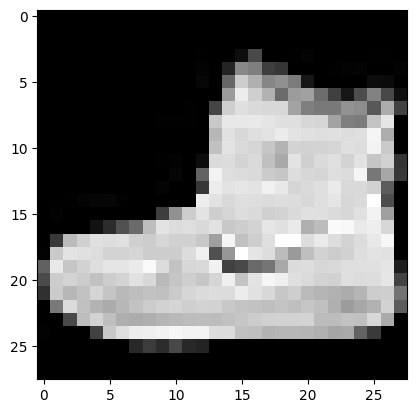

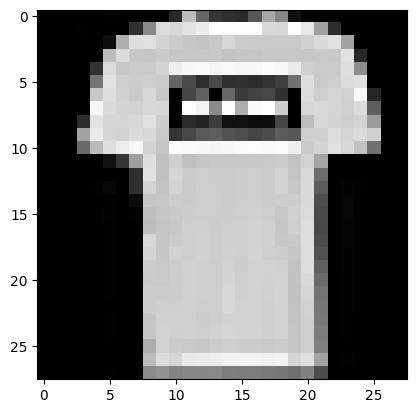

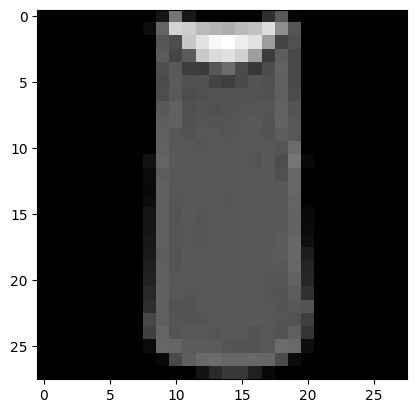

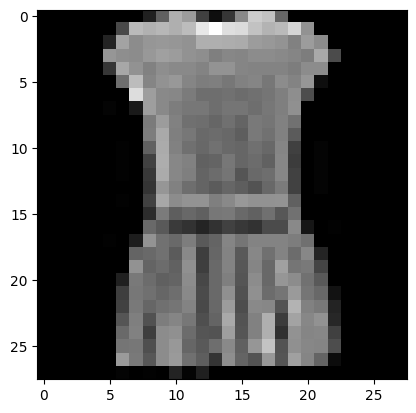

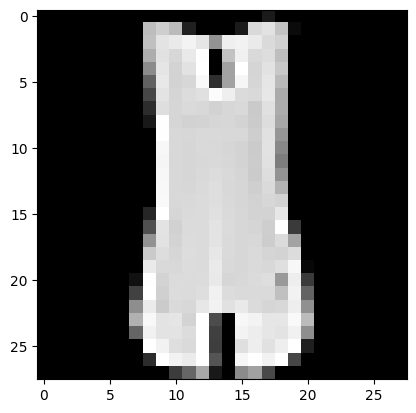

In [3]:
train_data = torchvision.datasets.FashionMNIST(root='fashion_mnist',download=True,train=True)

for i in range(5):
    plt.imshow(train_data[i][0], cmap='gray')
    plt.show()

## Посмотрим на размер изображения (28*28)

In [4]:
train_data[1]

(<PIL.Image.Image image mode=L size=28x28>, 0)

## Загружаем данные, делим трейн на трейн и валидацию, используем Dataloader, чтобы подавать данные батчами + используем трансформер для превращения данных в тензоры с последующей нормализацией

In [5]:
TRAIN_SIZE = 50000
VALIDATION_SIZE = 10000
BATCH_SIZE = 128

full_train_dataset = torchvision.datasets.FashionMNIST(root='fashion_mnist', train=True, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='fashion_mnist', train=False, download=True)

train_subset, val_subset = random_split(full_train_dataset, [TRAIN_SIZE, VALIDATION_SIZE])

# Считаем статистики только на трейне после сплита на трейн/вал, чтобы избежать утечки данных
train_data_pixels = full_train_dataset.data[train_subset.indices].float() / 255.0
mean, std = train_data_pixels.mean(), train_data_pixels.std()

# Применяем нормализацию(приводим данные к виду 0 среднее, и std 1, чтобы стабилизировать обучение)
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean.item(),), (std.item(),))
])

# Изменение родителя full_train_dataset приведёт к изменению и train_subset и val_subset
full_train_dataset.transform = transformer
test_dataset.transform = transformer

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
print(f"Кол-во батчей на трейне: {len(train_loader)}")
print(f"Кол-во батчей на валидации: {len(val_loader)}")
print(f"Кол-во батчей на тесте: {len(test_loader)}")

Кол-во батчей на трейне: 391
Кол-во батчей на валидации: 79
Кол-во батчей на тесте: 79


## Создадим класс EarlyStoping

In [7]:
# Класс, предназначенный для предотвращения переобучения с сохранением параметров системы
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth'):
        self.patience = patience    
        self.verbose = verbose      
        self.counter = 0           
        self.best_score = None      
        self.early_stop = False     
        self.val_loss_min = np.inf  
        self.delta = delta          
        self.path = path           

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## Функция обучения

In [8]:
def train(model, optimizer, epochs=10):

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        train_loss_avg = train_loss / len(train_loader)
        train_acc_avg = train_correct / train_total
        val_loss_avg = val_loss / len(val_loader)
        val_acc_avg = val_correct / val_total
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc_avg)
        history['val_acc'].append(val_acc_avg)

        early_stopping(val_loss_avg,model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Epoch {epoch+1} Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_acc'], label='Train Acc')
        plt.plot(history['val_acc'], label='Val Acc')
        plt.title(f'Epoch {epoch+1} Accuracy')
        plt.legend()
        
        plt.show()
        print(f"Epoch {epoch+1}: Train Loss {train_loss_avg:.4f}, Val Acc {val_acc_avg:.4f}, Val Loss {val_loss_avg:.4f}, Train Acc {train_acc_avg:.4f}")

## Создаём полносвязную архитектуру

In [9]:
class FullyConnectedNet(nn.Module): 
    def __init__(self):
        super(FullyConnectedNet, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.linear1 = nn.Linear(28*28, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        self.linear2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        
        self.linear3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        
        self.linear4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        
        x = self.relu1(self.linear1(x))
        x = self.dropout1(x)
        
        x = self.relu2(self.linear2(x))
        x = self.dropout2(x)
        
        x = self.relu3(self.linear3(x))
        x = self.dropout3(x)
        
        x = self.linear4(x)
        return x
model = FullyConnectedNet()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
summary(model, input_size=(BATCH_SIZE,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
FullyConnectedNet                        [128, 10]                 --
├─Flatten: 1-1                           [128, 784]                --
├─Linear: 1-2                            [128, 512]                401,920
├─ReLU: 1-3                              [128, 512]                --
├─Dropout: 1-4                           [128, 512]                --
├─Linear: 1-5                            [128, 256]                131,328
├─ReLU: 1-6                              [128, 256]                --
├─Dropout: 1-7                           [128, 256]                --
├─Linear: 1-8                            [128, 128]                32,896
├─ReLU: 1-9                              [128, 128]                --
├─Dropout: 1-10                          [128, 128]                --
├─Linear: 1-11                           [128, 10]                 1,290
Total params: 567,434
Trainable params: 567,434
Non-trainable params

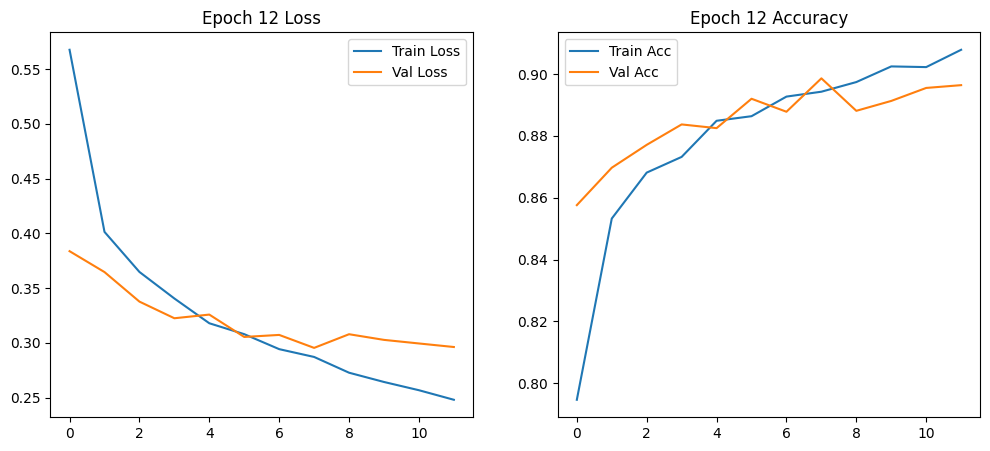

Epoch 12: Train Loss 0.2481, Val Acc 0.8964, Val Loss 0.2963, Train Acc 0.9078
Early stopping


In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stopping = EarlyStopping(patience=5,verbose=True,delta=0.001)
train(model,optimizer,epochs=50)

## Посмотрим на метрики для задач классификации

In [11]:
model.load_state_dict(torch.load('checkpoint.pth')) # Загружаем параметры модели, сохраненные EarlyStopiing
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Test Precision (macro): {precision_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Test Recall (macro): {recall_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Test F1 (macro): {f1_score(all_labels, all_preds, average='macro'):.4f}")

Test Accuracy: 0.8804
Test Precision (macro): 0.8816
Test Recall (macro): 0.8804
Test F1 (macro): 0.8805


## Вывод по использованию полносвязной архитектуры:
* Модель успешно обучилась и достигла точности на валидации около 89%, что хорошо для такой модели, которая не учитывает двумерные признаки, а разворачивает матрицу в плоский вектор.

* Анализируя графики функции потерь и точности , можно заметить признаки переобучения. Начиная примерно с 7 эпохи, ошибка на тренировочной выборке продолжает падать, а на валидационной начинает постепенно расти, в этом месте и срабатывает `EarlyStopping` не давая переобучиться нашей модели и сохраняя ее состояние до переобучения.

* Добавление слоев Dropout (0.2 и 0.3) помогло сгладить переобучение.